# Import libraries

In [1]:
# Перезагрузка модулей для применения изменений
import importlib
import TBMD.core.digital_twin.digital_twin as dt_module
importlib.reload(dt_module)

# Standard library imports
from pathlib import Path

# Third-party imports
import torch
import numpy as np
import matplotlib.pyplot as plt

import json
from pathlib import Path
from typing import Dict, Tuple

# Digital Twin imports (main module)
from TBMD.core.digital_twin import DigitalTwin
from TBMD.config.digital_twin_config import DigitalTwinConfig
from TBMD.models.ReservoirProxyModel import ReservoirState, WellControl

# TBMD utilities imports
from TBMD.utils.tbmd_utils import (
    reconstruct_tensor, 
    build_Y_matrices, 
    to_torch_tensor, 
    build_wells_matrix,
)
from TBMD.visualization.plots import (
    plot_two_matrices,
    plot_original_reconstructed_diff, 
    visualize_wells_placement, 
    visualize_tensor,
)
from TBMD.utils.metrics import compute_metrics

from TBMD.data_utils.loaders import DataLoader
from TBMD.data_utils.splitters import split_data_in_memory_ordered
from TBMD.data_utils.processors import (
    process_data, 
    calculate_global_minmax_params, 
    calculate_global_zscore_params, 
    inverse_normalization
)

from TBMD.config.base_config import BaseConfig

In [2]:
config = BaseConfig()
config._set_seed()
config.to_dict()

{'backend': 'pytorch',
 'dtype': 'float32',
 'device': 'cpu',
 'seed': 0,
 'deterministic': True,
 'verbose': True,
 'log_level': 'INFO'}

# Download data

In [22]:
loader = DataLoader()

### Load Brugge data

In [4]:
# Define paths relative to the project root
import os
from pathlib import Path

# Assuming the notebook is in algorithm/ and data is in data/
project_root = Path("..").resolve()
data_dir = project_root / "data" / "Brugge data"

tensors_path = data_dir / "data_exp_4_.h5"
wells_path = data_dir / "all_wells_exp_4.json"

print(f"Loading tensors from: {tensors_path}")
tensors = DataLoader.load_h5_tensors(str(tensors_path))
wells = DataLoader.load_wells_from_json(str(wells_path))

Loading tensors from: /Users/denissamatov/Heriot-Watt/Tensors/tensor-based-modal-decomposition-method/data/brugge/data_exp_4_.h5


In [5]:
for case_id in wells:
    # wells[case_id] is a list of [x,y] coordinate pairs.
    # This list comprehension iterates through each pair [x,y]
    # and creates a new pair [y,x], effectively swapping them.
    # The new list of swapped pairs replaces the original list for that case_id.
    wells[case_id] = [[y, x] for x, y in wells[case_id]]

# Display the modified wells dictionary
wells

{'case1': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],
  [36, 96],
  [27, 91],
  [44, 100],
  [33, 74],
  [34, 98],
  [41, 66],
  [37, 55],
  [42, 111],
  [42, 51],
  [41, 44]],
 'case10': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],
  [36, 96],
  [27, 91],
  [44, 100],
  [33, 74],
  [34, 98],
  [41, 66],
  [37, 55],
  [42, 111],
  [42, 51],
  [41, 44]],
 'case2': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],


In [6]:
# train_data, test_data = split_data_in_memory_ordered(tensors['all'], train_ratio=0.8)

# subject_name = list(tensors['all'].keys())[0]

# print(list(tensors['all'].keys()))
# print(tensors['all'][subject_name].shape)

In [7]:
train_data, test_data = split_data_in_memory_ordered(tensors['pressure'], train_ratio=0.8)

subject_name = list(tensors['pressure'].keys())[2]

print(list(tensors['pressure'].keys()))
print(tensors['pressure'][subject_name].shape)

Experiments processed: 100%|██████████| 10/10 [00:00<00:00, 59158.03it/s]

['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10']
(139, 48, 133)


In [8]:
# train_data, test_data = split_data_in_memory_ordered(tensors['soil'], train_ratio=0.8)

# subject_name = list(tensors['soil'].keys())[0]

# print(list(tensors['soil'].keys()))
# print(tensors['soil'][subject_name].shape)

# Process data

In [9]:
# Decide what counts as background (CT example)
BG = None        # Hounsfield Units for air

# 1.  Build masks once if you have them, otherwise just pass background_value
train_global_min, train_global_max = calculate_global_minmax_params(train_data,
                                                                    background_value=BG)
train_global_mean, train_global_std = calculate_global_zscore_params(train_data,
                                                                     background_value=BG)

# 2.  Pack the globals
minmax_params = {'min': train_global_min, 'max': train_global_max}
zscore_params = {'mean': train_global_mean, 'std': train_global_std}

print(minmax_params)
print(zscore_params)

{'min': 0.0, 'max': 171.8720422674243}
{'mean': 118.54628028736462, 'std': 70.1100889541879}


In [10]:
resize_shape = None
convert_to_grayscale = False
normalization_method = "minmax"  # "zscore" or "minmax"

print("Processing train data:")
train_tensors = process_data(
    train_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,                
    background_value=BG
)

print("\nProcessing test data:")
test_tensors = process_data(
    test_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,
    background_value=BG
)

num_images_train = {subject: tensor.shape[-1] for subject, tensor in train_tensors.items()}
num_images_test  = {subject: tensor.shape[-1] for subject, tensor in test_tensors.items()}

if num_images_train:
    min_train_images = min(num_images_train.values())
    print(f"\nMinimum number of images in train: {min_train_images}")
else:
    print("\nNo data available for analysis in train.")

if num_images_test:
    min_test_images = min(num_images_test.values())
    print(f"Minimum number of images in test: {min_test_images}")
else:
    print("No data available for analysis in test.")

Processing train data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 200.73it/s]


case1: (139, 48, 106)
case2: (139, 48, 106)
case3: (139, 48, 106)
case4: (139, 48, 106)
case5: (139, 48, 106)
case6: (139, 48, 106)
case7: (139, 48, 106)
case8: (139, 48, 106)
case9: (139, 48, 106)
case10: (139, 48, 106)

Processing test data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 887.25it/s]

case1: (139, 48, 27)
case2: (139, 48, 27)
case3: (139, 48, 27)
case4: (139, 48, 27)
case5: (139, 48, 27)
case6: (139, 48, 27)
case7: (139, 48, 27)
case8: (139, 48, 27)
case9: (139, 48, 27)
case10: (139, 48, 27)

Minimum number of images in train: 106
Minimum number of images in test: 27


# Digital Twin

## Setting up digital twin parameters

In [ ]:
# ============================================================================
# Настройка параметров Digital Twin
# ============================================================================

# Конфигурация для Digital Twin
# Адаптируем под размер ваших данных train_tensors
sample_subject = list(train_tensors.keys())[0]
sample_shape = train_tensors[sample_subject].shape
print(f"Размерность данных: {sample_shape}")
print(f"Subjects: {list(train_tensors.keys())}")

# =========================================================================
# Параметры для Brugge: меньше мод для устойчивости
# =========================================================================

n_spatial_modes = 32
n_temporal_modes = 10
n_sensors = 60  # авто-поднимется до числа мод при обучении

forecaster_type = 'lstm'  # фактический выбор делает ячейка экспериментов ниже
proxy_model_type = None

print(f"{'='*60}")
print(f"Параметры Digital Twin для Brugge данных:")
print(f"{'='*60}")
print(f"  Пространственные моды:  {n_spatial_modes} (из max {min(sample_shape[0], sample_shape[1])})")
print(f"  Временные моды:         {n_temporal_modes} (из max {sample_shape[2]})")
print(f"  Количество сенсоров:    {n_sensors} (из {sample_shape[0] * sample_shape[1]} точек)")
print(f"  Forecaster:             {forecaster_type}")
print(f"  Proxy model:            {proxy_model_type}")
print(f"{'='*60}")


Размерность данных: (139, 48, 106)
Subjects: ['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10']
Параметры Digital Twin для Brugge данных:
  Пространственные моды:  32 (из max 48)
  Временные моды:         10 (из max 106)
  Количество сенсоров:    60 (из 6672 точек)
  Forecaster:             lstm
  Proxy model:            None


In [12]:
# ============================================================================
# Функции для обучения и тестирования разных forecaster-ов
# ============================================================================

def evaluate_forecaster(twin, test_tensors, normalization_method, minmax_params, BG, subject=None, n_val_steps=10):
    """Метрики в норм/денорм шкале + baseline persistence (norm/denorm)."""
    if not test_tensors:
        return {'error': 'нет тестовых данных'}
    subj = subject or list(test_tensors.keys())[0]
    true_data = test_tensors[subj]
    if isinstance(true_data, np.ndarray):
        true_data = torch.from_numpy(true_data).float()
    n_steps = min(n_val_steps, true_data.shape[-1] - 1)
    if n_steps < 1:
        return {'error': 'слишком короткий ряд'}

    current_state = true_data[..., 0]
    ground_truth = true_data[..., 1:1 + n_steps]
    # use_history=False чтобы прогноз был чисто авто-регрессионный от current_state
    forecast = twin.predict(current_state, n_steps=n_steps, return_full_field=True, use_history=False)

    mse_norm, mae_norm, rmse_norm, r2_norm, rel_norm = [], [], [], [], []
    mse_persist_norm, mae_persist_norm = [], []
    persistence = current_state.unsqueeze(-1).repeat(1, 1, n_steps)

    for t in range(n_steps):
        gt_t = ground_truth[..., t]
        fc_t = forecast[..., t]
        diff = gt_t - fc_t
        mse = float(torch.mean(diff ** 2).item())
        mae = float(torch.mean(torch.abs(diff)).item())
        rmse = float(np.sqrt(mse))
        gt_flat = gt_t.reshape(-1)
        fc_flat = fc_t.reshape(-1)
        ss_res = float(torch.sum((gt_flat - fc_flat) ** 2).item())
        ss_tot = float(torch.sum((gt_flat - gt_flat.mean()) ** 2).item())
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)
        rel = float(torch.norm(diff) / (torch.norm(gt_t) + 1e-12))
        mse_norm.append(mse)
        mae_norm.append(mae)
        rmse_norm.append(rmse)
        r2_norm.append(r2)
        rel_norm.append(rel)

        p_t = persistence[..., t]
        p_diff = p_t - gt_t
        mse_p = float(torch.mean(p_diff ** 2).item())
        mae_p = float(torch.mean(torch.abs(p_diff)).item())
        mse_persist_norm.append(mse_p)
        mae_persist_norm.append(mae_p)

    def denorm(arr):
        return inverse_normalization(
            arr,
            normalization_method=normalization_method,
            global_params=minmax_params,
            background_value=BG
        )

    mse_denorm, mae_denorm, rmse_denorm, r2_denorm, rel_denorm = [], [], [], [], []
    mse_persist_denorm, mae_persist_denorm = [], []
    for t in range(n_steps):
        gt_d = denorm(ground_truth[..., t].cpu().numpy())
        fc_d = denorm(forecast[..., t].cpu().numpy())
        p_d = denorm(persistence[..., t].cpu().numpy())
        diff_d = gt_d - fc_d
        diff_p_d = p_d - gt_d
        mse = float(np.mean(diff_d ** 2))
        mae = float(np.mean(np.abs(diff_d)))
        rmse = float(np.sqrt(mse))
        gt_flat = gt_d.reshape(-1)
        fc_flat = fc_d.reshape(-1)
        ss_res = float(np.sum((gt_flat - fc_flat) ** 2))
        ss_tot = float(np.sum((gt_flat - gt_flat.mean()) ** 2))
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)
        rel = float(np.linalg.norm(diff_d) / (np.linalg.norm(gt_d) + 1e-12))
        mse_denorm.append(mse)
        mae_denorm.append(mae)
        rmse_denorm.append(rmse)
        r2_denorm.append(r2)
        rel_denorm.append(rel)

        mse_persist_denorm.append(float(np.mean(diff_p_d ** 2)))
        mae_persist_denorm.append(float(np.mean(np.abs(diff_p_d))))

    return {
        'subject': subj,
        'n_steps': n_steps,
        'mse_norm': mse_norm,
        'mae_norm': mae_norm,
        'rmse_norm': rmse_norm,
        'r2_norm': r2_norm,
        'rel_norm': rel_norm,
        'mse_norm_mean': float(np.mean(mse_norm)),
        'mae_norm_mean': float(np.mean(mae_norm)),
        'rmse_norm_mean': float(np.mean(rmse_norm)),
        'r2_norm_mean': float(np.mean(r2_norm)),
        'rel_norm_mean': float(np.mean(rel_norm)),
        'mse_denorm': mse_denorm,
        'mae_denorm': mae_denorm,
        'rmse_denorm': rmse_denorm,
        'r2_denorm': r2_denorm,
        'rel_denorm': rel_denorm,
        'mse_denorm_mean': float(np.mean(mse_denorm)),
        'mae_denorm_mean': float(np.mean(mae_denorm)),
        'rmse_denorm_mean': float(np.mean(rmse_denorm)),
        'r2_denorm_mean': float(np.mean(r2_denorm)),
        'rel_denorm_mean': float(np.mean(rel_denorm)),
        'persistence_mse_norm_mean': float(np.mean(mse_persist_norm)),
        'persistence_mae_norm_mean': float(np.mean(mae_persist_norm)),
        'persistence_mse_denorm_mean': float(np.mean(mse_persist_denorm)),
        'persistence_mae_denorm_mean': float(np.mean(mae_persist_denorm)),
    }


def train_and_eval_forecaster(forecaster_type, forecaster_config, *, epochs=300, batch_size=16, subject=None, n_val_steps=10):
    """Строит конфиг DigitalTwin, обучает и возвращает twin + метрики."""
    cfg = DigitalTwinConfig(
        n_spatial_modes=n_spatial_modes,
        n_temporal_modes=n_temporal_modes,
        n_sensors=n_sensors,
        forecaster_type=forecaster_type,
        forecaster_config=forecaster_config,
        proxy_model_type=proxy_model_type,
        epochs=epochs,
        batch_size=batch_size,
        early_stopping_patience=30,
        validation_split=0.2,
        device='cpu',
        dtype='float32',
        verbose=True,
    )
    twin_local = DigitalTwin(cfg)
    twin_local.train(train_tensors, normalize=False)
    metrics = evaluate_forecaster(
        twin_local,
        test_tensors,
        normalization_method,
        minmax_params,
        BG,
        subject=subject,
        n_val_steps=n_val_steps,
    )
    return twin_local, metrics


## Running experiments for forecaster: linear, mlp, lstm

In [13]:
# ============================================================================
# Запуск экспериментов для forecaster: linear, mlp, lstm
# Выбираем лучшую модель по MSE (денормализованной) и сохраняем её в twin
# ============================================================================

forecaster_tests = {
    'linear': {},
    'mlp': {
        'hidden_size': 768,
        'num_layers': 3,
        'dropout': 0.15,
        'learning_rate': 1e-4,
        'weight_decay': 1e-6,
        'seq_length': 20,
    },
    'lstm': {
        'hidden_size': 320,
        'num_layers': 2,
        'dropout': 0.2,
        'learning_rate': 5e-4,
        'weight_decay': 1e-6,
        'seq_length': 20,
    },
}

results = []
best_pair = None
n_val_steps = 10

for f_type, f_cfg in forecaster_tests.items():
    print(f"{'='*20} {f_type.upper()} {'='*20}")
    twin_local, metrics = train_and_eval_forecaster(
        f_type,
        f_cfg,
        epochs=300,
        batch_size=16,
        subject=None,
        n_val_steps=n_val_steps,
    )
    results.append({'forecaster': f_type, **metrics})
    if best_pair is None or metrics['mse_denorm_mean'] < best_pair[1]['mse_denorm_mean']:
        best_pair = (twin_local, metrics)

# Лучшая модель
if best_pair is None:
    raise RuntimeError("Эксперименты не запустились")

twin = best_pair[0]
best_metrics = best_pair[1]

print("Лучший forecaster по mse_denorm_mean:", best_metrics['mse_denorm_mean'])
for item in results:
    print(
        f"{item['forecaster']}: mse_denorm_mean={item.get('mse_denorm_mean'):.6f}, "
        f"rmse_denorm_mean={item.get('rmse_denorm_mean'):.6f}, "
        f"r2_denorm_mean={item.get('r2_denorm_mean'):.6f}, "
        f"persistence_mse_denorm_mean={item.get('persistence_mse_denorm_mean', float('nan')):.6f}"
    )

# Подготовка прогнозов текущей лучшей модели для последующих ячеек визуализации
first_key = list(train_tensors.keys())[0]
current_state = train_tensors[first_key][..., -1]
if isinstance(current_state, np.ndarray):
    current_state = torch.from_numpy(current_state).float()

print(f"Текущее состояние shape: {current_state.shape}")
print(f"Текущее состояние type: {type(current_state)}")

n_forecast_steps = 5
forecast = twin.predict(current_state, n_steps=n_forecast_steps, return_full_field=True)

print(f"Прогноз shape: {forecast.shape}")
print(f"Прогноз min/max: {forecast.min().item():.4f} / {forecast.max().item():.4f}")


==================== LINEAR ====================


n_sensors=60 меньше числа мод 100; устанавливаю n_sensors=100 для устойчивой реконструкции.


QR Factorization completed:
  Requested sensors: 100
  Actual rank: 100
  Success rate: 100.0%
  Early stops: 0
Using device: cpu
Training linear forecaster...
Training complete. RMSE: 0.00025, Rel. Frob. Err: 0.05782, R²: 0.99080
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
==================== MLP ====================
Using device: cpu
Training linear forecaster...
Training complete. RMSE: 0.00025, R

n_sensors=60 меньше числа мод 100; устанавливаю n_sensors=100 для устойчивой реконструкции.


QR Factorization completed:
  Requested sensors: 100
  Actual rank: 100
  Success rate: 100.0%
  Early stops: 0
Using device: cpu
Using device: cpu
Epoch 50/300 - Train loss: 0.000016 - Val loss: 0.000002
Epoch 50/300 - Train loss: 0.000016 - Val loss: 0.000002
Epoch 100/300 - Train loss: 0.000004 - Val loss: 0.000001
Epoch 100/300 - Train loss: 0.000004 - Val loss: 0.000001
Epoch 150/300 - Train loss: 0.000003 - Val loss: 0.000000
Early stopping triggered after 150 epochs.
Training complete!
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mod

n_sensors=60 меньше числа мод 100; устанавливаю n_sensors=100 для устойчивой реконструкции.


QR Factorization completed:
  Requested sensors: 100
  Actual rank: 100
  Success rate: 100.0%
  Early stops: 0
Using device: cpu
Using device: cpu
Epoch 50/300 - Train loss: 0.000000 - Val loss: 0.000000
Early stopping triggered after 52 epochs.
Training complete!
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Лучший forecaster по mse_denorm_mean: 9.642118167877197
linear: mse_denorm_mean=9.642118, rmse

## Reconstruction by sensors

In [14]:
# ============================================================================
# Реконструкция по сенсорам
# ============================================================================

# Получаем позиции сенсоров
sensor_indices = twin.get_sensor_locations()
print(f"Количество сенсоров: {len(sensor_indices)}")
print(f"Первые 10 индексов сенсоров: {sensor_indices[:10]}")

# Создаём псевдо-измерения из прогноза первого шага
# Flatten прогноз и извлекаем значения на позициях сенсоров
forecast_step_0 = forecast[..., 0] if forecast.ndim > 2 else forecast
flat_forecast = forecast_step_0.reshape(-1)
sensor_readings = flat_forecast[sensor_indices]

print(f"Измерения сенсоров shape: {sensor_readings.shape}")
print(f"Измерения min/max: {sensor_readings.min().item():.4f} / {sensor_readings.max().item():.4f}")

# Реконструируем полное поле по измерениям сенсоров
reconstructed = twin.update_from_sensors(sensor_readings)
print(f"Реконструкция shape: {reconstructed.shape}")

Нормализация не настроена внутри DigitalTwin. Ожидаются заранее нормализованные измерения сенсоров.


Количество сенсоров: 100
Первые 10 индексов сенсоров: [ 77  93 117 125 127 133 135 138 139 143]
Измерения сенсоров shape: torch.Size([100])
Измерения min/max: -0.0585 / 1.0645
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Реконструкция shape: torch.Size([139, 48])


## Visualization of results

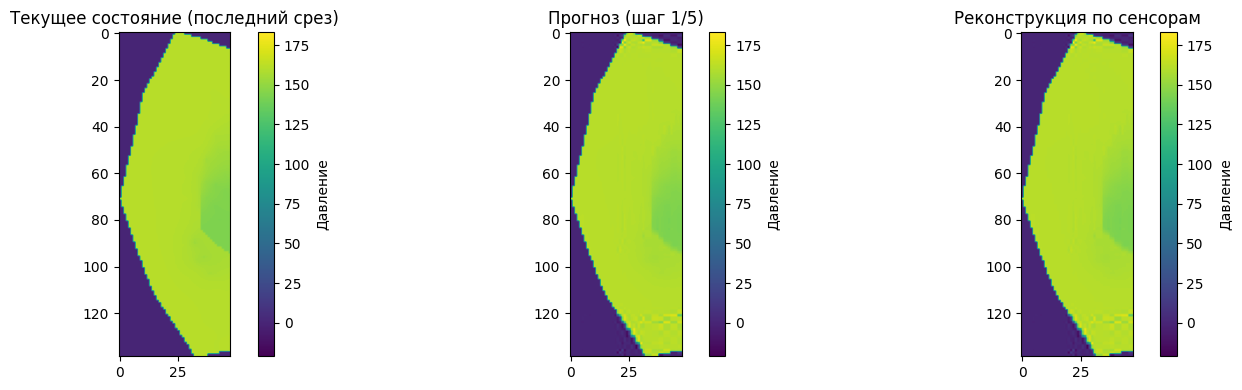


Диапазон значений (в исходной шкале):
  Текущее состояние: [0.00, 161.49]
  Прогноз:           [-21.12, 182.96]
  Реконструкция:     [-21.14, 183.04]


In [15]:
# ============================================================================
# Визуализация результатов (в исходной шкале)
# ============================================================================

# Обратная нормализация для отображения в реальных единицах
original_current_state = inverse_normalization(
    current_state.cpu().numpy(), 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)

forecast_step = forecast[..., 0].cpu().numpy() if forecast.ndim > 2 else forecast.cpu().numpy()
original_forecast = inverse_normalization(
    forecast_step, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)

reconstructed_step = reconstructed.cpu().numpy() if reconstructed.ndim == 2 else reconstructed[..., 0].cpu().numpy()
original_reconstructed = inverse_normalization(
    reconstructed_step, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)

# Определяем общую шкалу для всех графиков
vmin = min(original_current_state.min(), original_forecast.min(), original_reconstructed.min())
vmax = max(original_current_state.max(), original_forecast.max(), original_reconstructed.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Текущее состояние
im0 = axes[0].imshow(original_current_state, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Текущее состояние (последний срез)')
plt.colorbar(im0, ax=axes[0], label='Давление')

# Прогноз (первый шаг)
im1 = axes[1].imshow(original_forecast, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Прогноз (шаг 1/{n_forecast_steps})')
plt.colorbar(im1, ax=axes[1], label='Давление')

# Реконструкция
im2 = axes[2].imshow(original_reconstructed, cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title('Реконструкция по сенсорам')
plt.colorbar(im2, ax=axes[2], label='Давление')

plt.tight_layout()
plt.show()

print(f"\nДиапазон значений (в исходной шкале):")
print(f"  Текущее состояние: [{original_current_state.min():.2f}, {original_current_state.max():.2f}]")
print(f"  Прогноз:           [{original_forecast.min():.2f}, {original_forecast.max():.2f}]")
print(f"  Реконструкция:     [{original_reconstructed.min():.2f}, {original_reconstructed.max():.2f}]")

## Quality assessment on test data


==================== LINEAR ====================


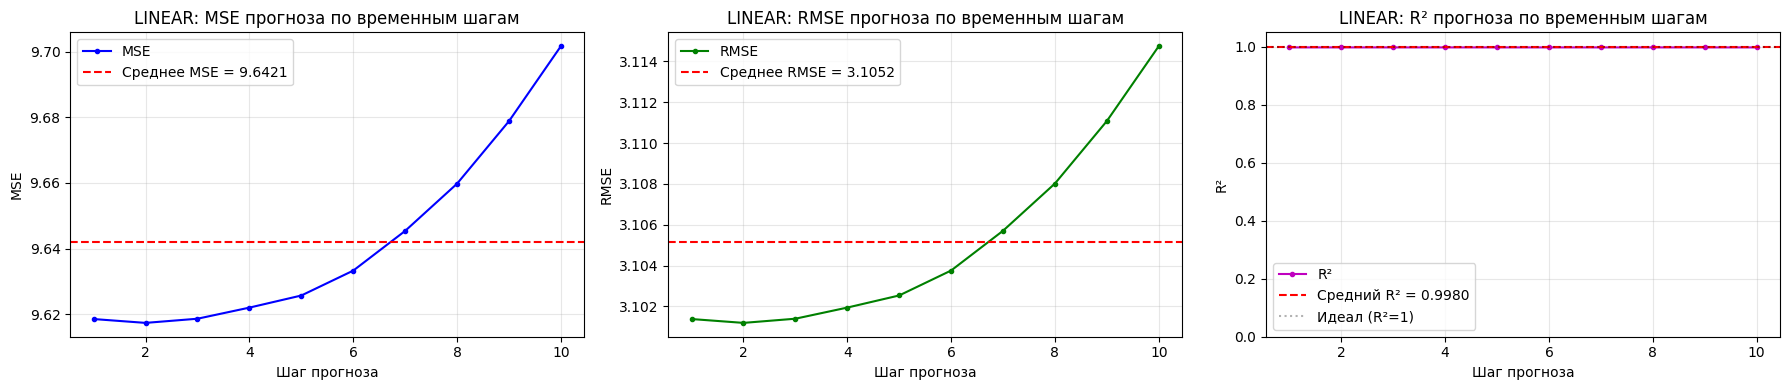


==================== MLP ====================


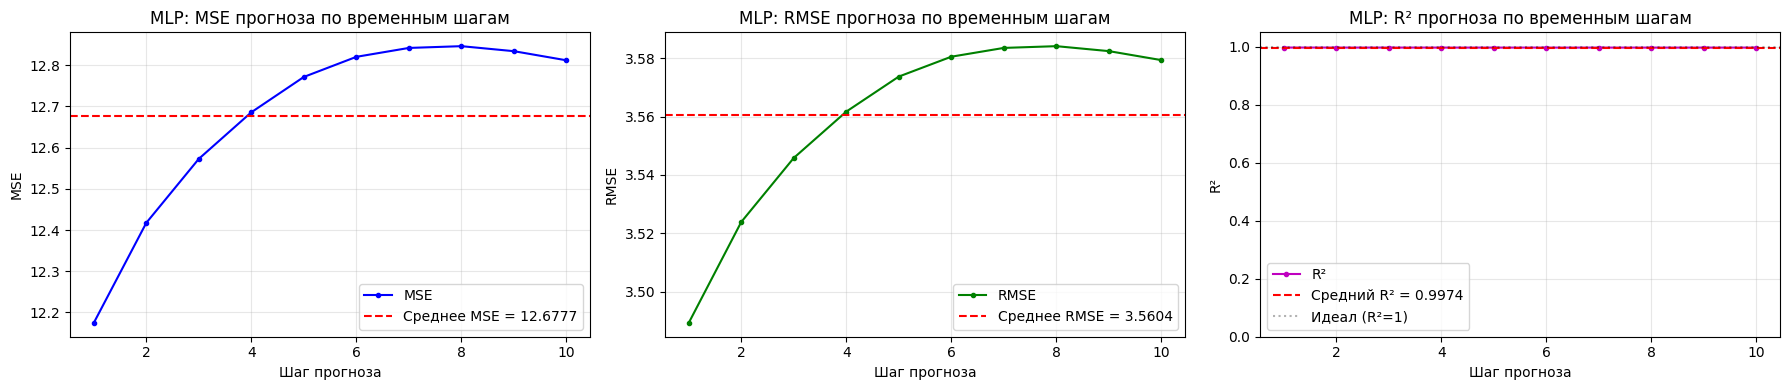


==================== LSTM ====================


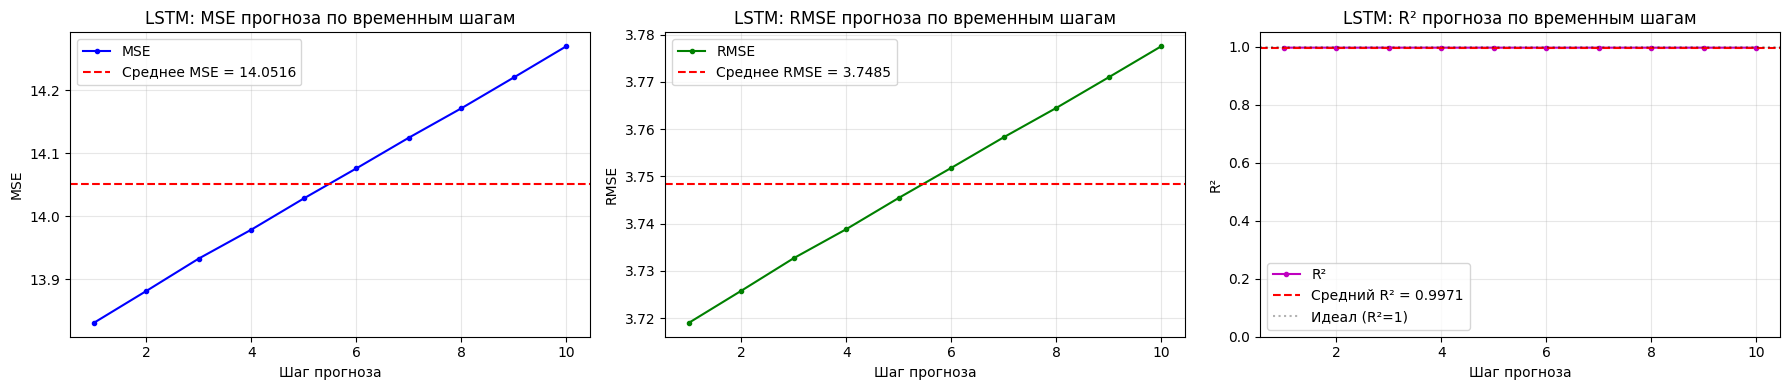

In [19]:
# ============================================================================
# Оценка качества на тестовых данных (в денормализованной шкале + R²)
# ============================================================================

if 'results' in globals() and results:
    for res in results:
        forecaster_name = res['forecaster'].upper()
        print(f"\n{'='*20} {forecaster_name} {'='*20}")
        
        # Извлекаем метрики из результатов
        mse_per_step = res['mse_denorm']
        rmse_per_step = res['rmse_denorm']
        r2_per_step = res['r2_denorm']
        
        steps_range = range(1, len(mse_per_step) + 1)
        
        # ========================================================================
        # Графики метрик по времени (MSE, RMSE, R² - отдельно)
        # ========================================================================
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        
        # MSE plot
        axes[0].plot(steps_range, mse_per_step, 'b-o', label='MSE', markersize=3)
        axes[0].axhline(y=np.mean(mse_per_step), color='r', linestyle='--', label=f'Среднее MSE = {np.mean(mse_per_step):.4f}')
        axes[0].set_xlabel('Шаг прогноза')
        axes[0].set_ylabel('MSE')
        axes[0].set_title(f'{forecaster_name}: MSE прогноза по временным шагам')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # RMSE plot (отдельно)
        axes[1].plot(steps_range, rmse_per_step, 'g-o', label='RMSE', markersize=3)
        axes[1].axhline(y=np.mean(rmse_per_step), color='r', linestyle='--', label=f'Среднее RMSE = {np.mean(rmse_per_step):.4f}')
        axes[1].set_xlabel('Шаг прогноза')
        axes[1].set_ylabel('RMSE')
        axes[1].set_title(f'{forecaster_name}: RMSE прогноза по временным шагам')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # R² plot (отдельно)
        axes[2].plot(steps_range, r2_per_step, 'm-o', label='R²', markersize=3)
        axes[2].axhline(y=np.mean(r2_per_step), color='r', linestyle='--', label=f'Средний R² = {np.mean(r2_per_step):.4f}')
        axes[2].axhline(y=1.0, color='k', linestyle=':', alpha=0.3, label='Идеал (R²=1)')
        axes[2].set_xlabel('Шаг прогноза')
        axes[2].set_ylabel('R²')
        axes[2].set_title(f'{forecaster_name}: R² прогноза по временным шагам')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        axes[2].set_ylim([min(0, min(r2_per_step) - 0.1), 1.05])
        
        plt.tight_layout()
        plt.show()

else:
    print("Результаты экспериментов (переменная 'results') не найдены. Запустите ячейку с обучением моделей.")

## Summary table of metrics

In [21]:
# ============================================================================
# Сводная таблица метрик по forecaster-ам (linear / mlp / lstm)
# ==========================================================================
import pandas as pd

if 'results' not in globals() or not results:
    print('Нет результатов для сводной таблицы. Сначала запустите ячейку с тестами forecaster-ов.')
else:
    # 1. Сводная таблица (средние значения)
    rows = []
    for r in results:
        rows.append({
            'forecaster': r.get('forecaster'),
            'subject': r.get('subject'),
            'n_steps': r.get('n_steps'),
            'mse_denorm_mean': r.get('mse_denorm_mean'),
            'rmse_denorm_mean': r.get('rmse_denorm_mean'),
            'r2_denorm_mean': r.get('r2_denorm_mean'),
            'rel_denorm_mean': r.get('rel_denorm_mean'),
            'mse_norm_mean': r.get('mse_norm_mean'),
            'rmse_norm_mean': r.get('rmse_norm_mean'),
            'r2_norm_mean': r.get('r2_norm_mean'),
            'rel_norm_mean': r.get('rel_norm_mean'),
            'persistence_mse_norm_mean': r.get('persistence_mse_norm_mean'),
            'persistence_mae_norm_mean': r.get('persistence_mae_norm_mean'),
            'persistence_mse_denorm_mean': r.get('persistence_mse_denorm_mean'),
            'persistence_mae_denorm_mean': r.get('persistence_mae_denorm_mean'),
        })
    summary_df = pd.DataFrame(rows)
    
    print("Сводная таблица (средние значения):")
    if not summary_df.empty:
        summary_df = summary_df.sort_values('mse_denorm_mean')
        display(summary_df.round(6))
    else:
        print('Пустой результат.')

    # 2. Детальная таблица по шагам (MSE, RMSE, R2)
    print("\nДетальные метрики по каждому шагу прогноза (денормализованные):")
    step_rows = []
    for r in results:
        f_name = r.get('forecaster')
        # Списки метрик по шагам
        mse_steps = r.get('mse_denorm', [])
        rmse_steps = r.get('rmse_denorm', [])
        r2_steps = r.get('r2_denorm', [])
        
        for i, (mse, rmse, r2) in enumerate(zip(mse_steps, rmse_steps, r2_steps)):
            step_rows.append({
                'Step': i + 1,
                'Forecaster': f_name,
                'MSE': np.round(mse, 3),
                'RMSE': np.round(rmse, 3),
                'R2': np.round(r2, 3)
            })
            
    steps_df = pd.DataFrame(step_rows)
    if not steps_df.empty:
        # Создаем сводную таблицу: Индекс=Step, Колонки=Forecaster, Значения=Метрики
        # pivot создает MultiIndex в колонках (Metric, Forecaster)
        pivot_steps = steps_df.pivot(index='Step', columns='Forecaster', values=['MSE', 'RMSE', 'R2'])
        
        # Можно поменять уровни местами, чтобы группировать по Forecaster, если нужно:
        # pivot_steps = pivot_steps.swaplevel(0, 1, axis=1).sort_index(axis=1)
        
        display(pivot_steps.round(6))
    else:
        print("Нет данных по шагам.")

Сводная таблица (средние значения):


,forecaster,subject,n_steps,mse_denorm_mean,rmse_denorm_mean,r2_denorm_mean,rel_denorm_mean,mse_norm_mean,rmse_norm_mean,r2_norm_mean,rel_norm_mean,persistence_mse_norm_mean,persistence_mae_norm_mean,persistence_mse_denorm_mean,persistence_mae_denorm_mean
0,linear,case1,10,9.642118,3.105173,0.998012,0.022677,0.000326,0.018067,0.998012,0.022677,0.0,0.000319,0.005472,0.054753
1,mlp,case1,10,12.677697,3.560447,0.997386,0.026002,0.000429,0.020716,0.997386,0.026002,0.0,0.000319,0.005472,0.054753
2,lstm,case1,10,14.051621,3.748503,0.997102,0.027375,0.000476,0.021810,0.997102,0.027375,0.0,0.000319,0.005472,0.054753



Детальные метрики по каждому шагу прогноза (денормализованные):


MSE                   RMSE                   R2              
Forecaster linear    lstm     mlp linear   lstm    mlp linear   lstm    mlp
Step                                                                       
1           9.619  13.831  12.175  3.101  3.719  3.489  0.998  0.997  0.997
2           9.617  13.882  12.418  3.101  3.726  3.524  0.998  0.997  0.997
3           9.619  13.933  12.573  3.101  3.733  3.546  0.998  0.997  0.997
4           9.622  13.979  12.686  3.102  3.739  3.562  0.998  0.997  0.997
5           9.626  14.028  12.772  3.103  3.745  3.574  0.998  0.997  0.997
6           9.633  14.076  12.820  3.104  3.752  3.581  0.998  0.997  0.997
7           9.645  14.125  12.842  3.106  3.758  3.584  0.998  0.997  0.997
8           9.660  14.172  12.846  3.108  3.765  3.584  0.998  0.997  0.997
9           9.679  14.220  12.834  3.111  3.771  3.582  0.998  0.997  0.997
10          9.702  14.270  12.812  3.115  3.778  3.579  0.998  0.997  0.997